In [40]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report ,f1_score, recall_score
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
df = pd.read_parquet(r"C:\Users\moham\Downloads\2026_geoai_arctic_challenge_v1.0\Dataframe_prep\clean_pixel_dataframe")



In [3]:
display(df.describe())

,R,G,B,ndvi,ndwi,nir,relative_elevation,shaded_relief,target
count,2.370587e+07,2.370587e+07,2.370587e+07,2.370587e+07,2.370587e+07,2.370587e+07,2.370587e+07,2.370587e+07,2.370587e+07
mean,9.320612e+01,9.667075e+01,7.774488e+01,3.916776e-01,7.537879e-03,1.644361e+02,2.212854e+03,-3.811165e-01,7.684291e-02
std,3.738335e+01,3.088534e+01,3.076078e+01,3.587638e-01,1.378531e+00,1.955409e+01,8.481379e+02,3.716138e-01,2.588807e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,-9.961686e-01,-3.358863e+02,1.428004e+02,7.300000e+01,-8.090887e-01,0.000000e+00
25%,6.800000e+01,7.700000e+01,5.700000e+01,1.975224e-01,-2.564697e-01,1.558857e+02,1.606500e+03,-6.304821e-01,0.000000e+00
50%,8.600000e+01,9.000000e+01,7.000000e+01,5.789765e-01,-1.541138e-03,1.657343e+02,2.522179e+03,-5.852990e-01,0.000000e+00
75%,1.150000e+02,1.110000e+02,9.300000e+01,6.592997e-01,2.563477e-01,1.731765e+02,2.901000e+03,-2.774903e-01,0.000000e+00
max,2.550000e+02,2.550000e+02,2.550000e+02,8.929206e-01,3.113236e+02,1.888416e+02,7.310614e+03,9.981966e-01,1.000000e+00


In [5]:
df["target"].value_counts()

target
0.0    21884240
1.0     1821628
Name: count, dtype: int64

In [10]:
# Sample 36 lakhs
df_0 = df[df["target"] == 0]
df_1 = df[df["target"] == 1 ]

In [18]:
df_sampled= df_0.sample(n =3643256,random_state = 42)
df_final = pd.concat([df_sampled , df_1] , ignore_index = True)

In [19]:
df_final["target"].value_counts()

target
0.0    3643256
1.0    1821628
Name: count, dtype: int64

In [23]:
X = df_final.drop('target' , axis = 1)
Y = df_final["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42 , stratify = Y
)

In [35]:
params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':200,
    'alpha':10
}

model = XGBClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.8663827124197757

Classification Report
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90   1092977
         1.0       0.80      0.80      0.80    546489

    accuracy                           0.87   1639466
   macro avg       0.85      0.85      0.85   1639466
weighted avg       0.87      0.87      0.87   1639466



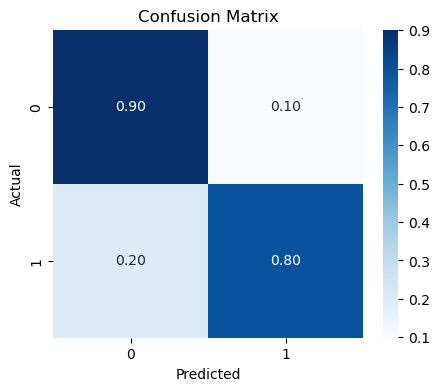

In [37]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred, normalize= 'true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 800x600 with 0 Axes>

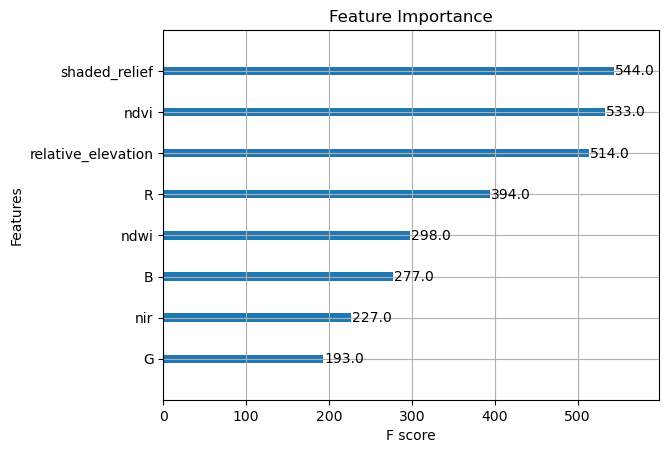

In [38]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

In [43]:
depths = [2, 3, 4, 5, 6, 8 , 15,25]

accuracies = []
f1_scores = []
recalls = []

for depth in depths:

    model = XGBClassifier(
        objective='binary:logistic',
        max_depth=depth,
        learning_rate=0.1,
        n_estimators=200,
        alpha=10
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))

In [46]:
print("f1_scores",f1_scores)
print("accuracies" ,accuracies)
print("recall" , recalls)

f1_scores [0.7618698598031278, 0.786100532036608, 0.7989404634829785, 0.8076990942510955, 0.8147002428735779, 0.8290145449286488, 0.8706500257096821, 0.899556099414239]
accuracies [0.8466153003477962, 0.859166948262422, 0.8663827124197757, 0.8717039572641335, 0.876213352396451, 0.8853376648250101, 0.9126929134242491, 0.9321089915862848]
recall [0.7361044778577428, 0.7763614638172041, 0.7964222518660028, 0.808299892587042, 0.816371418271914, 0.8339015057942611, 0.8814907527873388, 0.9120275065005883]


In [47]:
depths = [35,50,65]


for depth in depths:

    model = XGBClassifier(
        objective='binary:logistic',
        max_depth=depth,
        learning_rate=0.1,
        n_estimators=200,
        alpha=10
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))

In [50]:
print("f1_scores",f1_scores)
print("accuracies" ,accuracies)
print("recall" , recalls)

f1_scores [0.7618698598031278, 0.786100532036608, 0.7989404634829785, 0.8076990942510955, 0.8147002428735779, 0.8290145449286488, 0.8706500257096821, 0.899556099414239, 0.9063658980390741, 0.9079242084871966, 0.9082913006312586]
accuracies [0.8466153003477962, 0.859166948262422, 0.8663827124197757, 0.8717039572641335, 0.876213352396451, 0.8853376648250101, 0.9126929134242491, 0.9321089915862848, 0.9367544066177645, 0.9378413459016534, 0.9380944771041303]
recall [0.7361044778577428, 0.7763614638172041, 0.7964222518660028, 0.808299892587042, 0.816371418271914, 0.8339015057942611, 0.8814907527873388, 0.9120275065005883, 0.9183130858992588, 0.9193835557531808, 0.9196763338328859]


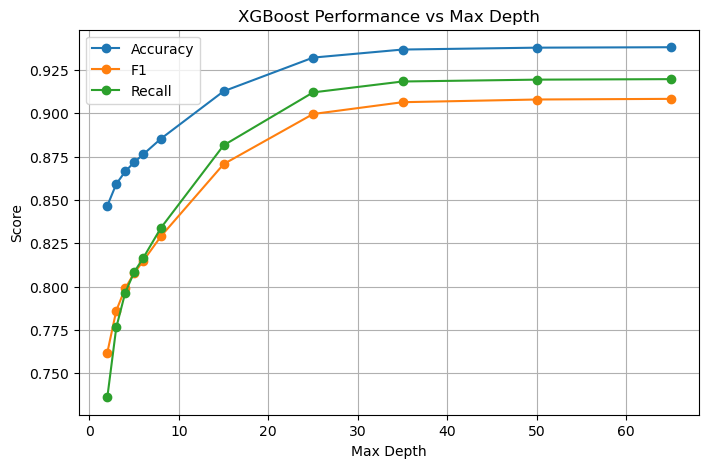

In [49]:
depths = [2, 3, 4, 5, 6, 8 , 15,25,35,50,65]
plt.figure(figsize=(8, 5))

plt.plot(depths, accuracies, marker='o', label='Accuracy')
plt.plot(depths, f1_scores, marker='o', label='F1')
plt.plot(depths, recalls, marker='o', label='Recall')

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("XGBoost Performance vs Max Depth")
plt.legend()
plt.grid(True)

plt.show()

# Final model for no preprocessed dataset -> ONLY drop duplicates and drop nan values

In [51]:
params = {
    'objective':'binary:logistic',
    'max_depth':14,
    'learning_rate':0.1,
    'n_estimators':200,
    'alpha':10
}

model = XGBClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [52]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9094589335795924

Classification Report
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93   1092977
         1.0       0.86      0.88      0.87    546489

    accuracy                           0.91   1639466
   macro avg       0.90      0.90      0.90   1639466
weighted avg       0.91      0.91      0.91   1639466



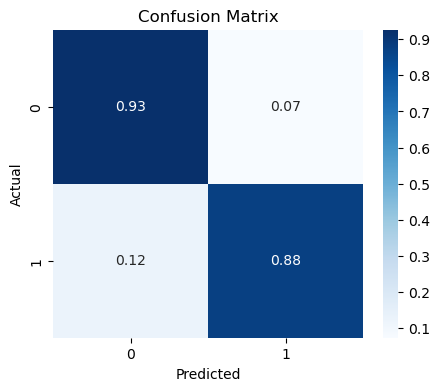

In [53]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred, normalize= 'true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 800x600 with 0 Axes>

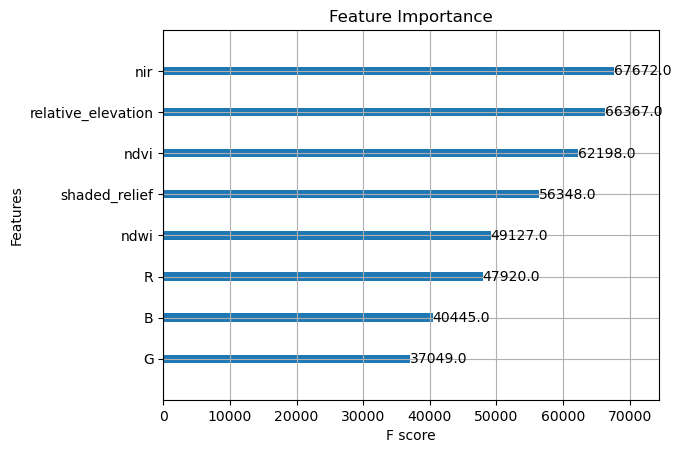

In [54]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

Keys inside NPZ: ['image']
Input shape: (157, 290, 8)
Input dtype: float32
H = 157
W = 290
X_test shape: (45530, 8)
Number of predictions: 45530
Expected: 45530
Number of connected components: 71


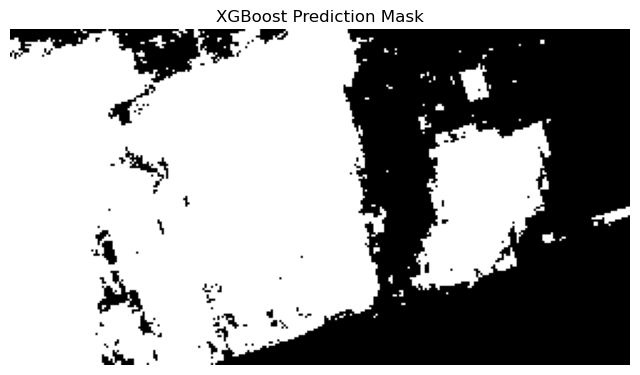

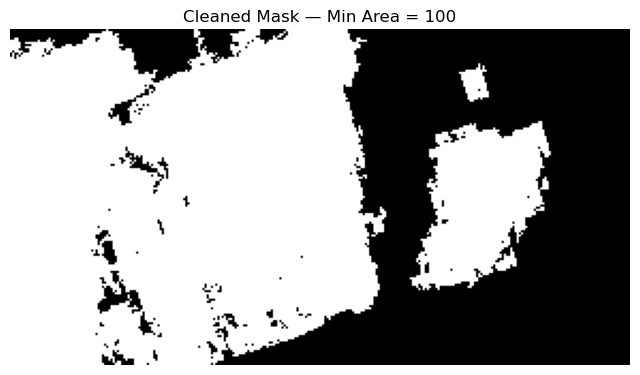

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


npz_path = r"C:\Users\moham\Downloads\2026_geoai_arctic_challenge_v1.0\competition_release\train\images\train_000461.npz"

data = np.load(npz_path)

print("Keys inside NPZ:", data.files)


image = data[data.files[0]]

print("Input shape:", image.shape)
print("Input dtype:", image.dtype)



H, W = image.shape[:2]

print("H =", H)
print("W =", W)



if image.ndim == 3:

    X_test = image.reshape(-1, image.shape[-1])

else:
    raise ValueError(
        f"Unexpected image shape: {image.shape}"
    )

print("X_test shape:", X_test.shape)



y_pred = model.predict(X_test)

print("Number of predictions:", len(y_pred))
print("Expected:", H * W)


pred_mask = y_pred.reshape(H, W).astype(np.uint8)



num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    pred_mask,
    connectivity=8
)

print("Number of connected components:", num_labels - 1)


min_area = 100

clean_mask = np.zeros_like(pred_mask)

for component_id in range(1, num_labels):

    area = stats[component_id, cv2.CC_STAT_AREA]

    if area >= min_area:
        clean_mask[labels == component_id] = 1


plt.figure(figsize=(8, 6))

plt.imshow(pred_mask, cmap="gray")
plt.title("XGBoost Prediction Mask")
plt.axis("off")

plt.show()


plt.figure(figsize=(8, 6))

plt.imshow(clean_mask, cmap="gray")
plt.title(f"Cleaned Mask — Min Area = {min_area}")
plt.axis("off")

plt.show()

In [73]:
min_area = 1000  # Minimum instance pixel count
max_area = 50000

final_instances = []
unique_labels = np.unique(labels)

for label_id in unique_labels:
    if label_id <= 1:  # Skip background (1) and boundary (-1)
        continue
    
    instance_mask = np.uint8(labels == label_id)
    area = np.sum(instance_mask)
    
    if min_area <= area <= max_area:
        final_instances.append((label_id, instance_mask, area))

print(f"Detected {len(final_instances)} valid instances.")

Detected 2 valid instances.


# Evaluation 

In [ ]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pycocotools import mask as maskUtils
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    confusion_matrix,
    average_precision_score
)


# ============================================================
# CONFIGURATION
# ============================================================

GT_JSON = r"C:\Users\moham\Downloads\2026_geoai_arctic_challenge_v1.0\competition_release\train\annotations\instances_train.json"

OUTPUT_DIR = "rts_evaluation"

THRESHOLD = 0.5
MIN_AREA = 10
CONNECTIVITY = 8

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# LOAD COCO DATASET
# ============================================================

coco_gt = COCO(GT_JSON)

image_ids = coco_gt.getImgIds()

print(f"Number of images: {len(image_ids)}")
print(f"Number of annotations: {len(coco_gt.getAnnIds())}")


# ============================================================
# DECODE ONE COCO RLE MASK
# ============================================================

def decode_rle(rle):
    """
    Decode a COCO compressed RLE annotation.

    Returns
    -------
    mask : np.ndarray
        Binary mask with shape H x W.
    """

    mask = maskUtils.decode(rle)

    # Some RLE decodings can have an extra channel dimension
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    return mask.astype(np.uint8)


# ============================================================
# GET GROUND-TRUTH INSTANCES
# ============================================================

def get_gt_instances(coco, image_id):
    """
    Returns the individual GT instance masks for one image.
    """

    ann_ids = coco.getAnnIds(
        imgIds=[image_id],
        catIds=[1],
        iscrowd=None
    )

    anns = coco.loadAnns(ann_ids)

    instances = []

    for ann in anns:

        mask = decode_rle(ann["segmentation"])

        instances.append({
            "id": ann["id"],
            "mask": mask,
            "area": ann["area"],
            "bbox": ann["bbox"]
        })

    return instances


# ============================================================
# CREATE BINARY GT MASK
# ============================================================

def get_gt_binary_mask(coco, image_id, height, width):

    gt_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    instances = get_gt_instances(coco, image_id)

    for instance in instances:

        mask = instance["mask"]

        gt_mask[mask > 0] = 1

    return gt_mask


# ============================================================
# CONNECTED COMPONENT INSTANCE EXTRACTION
# ============================================================

def probability_to_instances(
    probability_map,
    threshold=0.5,
    min_area=10,
    connectivity=8
):
    """
    Convert an XGBoost probability map into instance masks.

    Parameters
    ----------
    probability_map : H x W
        XGBoost probability for RTS class.

    threshold : float
        Pixel-level probability threshold.

    min_area : int
        Minimum component size.

    connectivity : int
        4 or 8 connected components.

    Returns
    -------
    binary_mask : H x W
        Thresholded semantic mask.

    instance_labels : H x W
        Each connected component has a unique integer ID.

    instances : list
        List of predicted instance dictionaries.
    """

    # --------------------------------------------------------
    # STEP 1: threshold probability
    # --------------------------------------------------------

    binary_mask = (
        probability_map >= threshold
    ).astype(np.uint8)


    # --------------------------------------------------------
    # STEP 2: connected components
    # --------------------------------------------------------

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=connectivity
        )


    # --------------------------------------------------------
    # STEP 3: remove small components
    # --------------------------------------------------------

    cleaned_labels = np.zeros_like(labels)

    instances = []

    new_instance_id = 1

    for component_id in range(1, num_labels):

        area = stats[
            component_id,
            cv2.CC_STAT_AREA
        ]

        if area < min_area:
            continue


        # Create mask for this component
        component_mask = (
            labels == component_id
        ).astype(np.uint8)


        # Assign a new instance ID
        cleaned_labels[
            component_mask > 0
        ] = new_instance_id


        # ----------------------------------------------------
        # Instance confidence
        # ----------------------------------------------------

        component_probabilities = probability_map[
            component_mask > 0
        ]

        score = float(
            component_probabilities.mean()
        )


        # ----------------------------------------------------
        # Bounding box
        # ----------------------------------------------------

        x = stats[
            component_id,
            cv2.CC_STAT_LEFT
        ]

        y = stats[
            component_id,
            cv2.CC_STAT_TOP
        ]

        w = stats[
            component_id,
            cv2.CC_STAT_WIDTH
        ]

        h = stats[
            component_id,
            cv2.CC_STAT_HEIGHT
        ]


        instances.append({

            "id": new_instance_id,

            "mask": component_mask,

            "area": int(area),

            "bbox": [
                int(x),
                int(y),
                int(w),
                int(h)
            ],

            "score": score

        })

        new_instance_id += 1


    return binary_mask, cleaned_labels, instances


# ============================================================
# CONVERT MASK → COCO RLE
# ============================================================

def mask_to_rle(mask):

    """
    Convert binary H x W mask to COCO compressed RLE.
    """

    mask = np.asfortranarray(
        mask.astype(np.uint8)
    )

    rle = maskUtils.encode(mask)

    # pycocotools returns bytes for counts
    if isinstance(rle["counts"], bytes):
        rle["counts"] = \
            rle["counts"].decode("ascii")

    return rle


# ============================================================
# BUILD COCO PREDICTION JSON
# ============================================================

def build_coco_predictions(
    coco,
    prob_maps,
    threshold=0.5,
    min_area=10,
    connectivity=8
):

    predictions = []

    all_prediction_data = {}

    for image_id, probability_map in prob_maps.items():

        probability_map = np.asarray(
            probability_map
        )

        height, width = probability_map.shape


        # ----------------------------------------------------
        # Check image dimensions
        # ----------------------------------------------------

        image_info = coco.loadImgs([image_id])[0]

        expected_height = image_info["height"]
        expected_width = image_info["width"]

        if (
            height != expected_height
            or width != expected_width
        ):

            raise ValueError(
                f"Image {image_id}: "
                f"probability map has shape "
                f"{probability_map.shape}, "
                f"but COCO says "
                f"{expected_height} x "
                f"{expected_width}"
            )


        # ----------------------------------------------------
        # Extract instances
        # ----------------------------------------------------

        binary_mask, instance_labels, instances = \
            probability_to_instances(
                probability_map,
                threshold=threshold,
                min_area=min_area,
                connectivity=connectivity
            )


        all_prediction_data[image_id] = {

            "probability": probability_map,

            "binary_mask": binary_mask,

            "instance_labels": instance_labels,

            "instances": instances
        }


        # ----------------------------------------------------
        # Convert each instance to COCO prediction
        # ----------------------------------------------------

        for instance in instances:

            rle = mask_to_rle(
                instance["mask"]
            )

            predictions.append({

                "image_id": int(image_id),

                "category_id": 1,

                "segmentation": rle,

                "score": instance["score"]

            })


    return predictions, all_prediction_data


# ============================================================
# SAVE COCO PREDICTIONS
# ============================================================

def save_predictions(predictions, path):

    with open(path, "w") as f:

        json.dump(
            predictions,
            f
        )

    print(
        f"Saved predictions to: {path}"
    )


# ============================================================
# INSTANCE SEGMENTATION mAP
# ============================================================

def evaluate_coco(
    coco_gt,
    predictions,
    image_ids
):

    if len(predictions) == 0:

        print(
            "WARNING: No predicted instances!"
        )

        return None


    prediction_json = os.path.join(
        OUTPUT_DIR,
        "predictions.json"
    )

    save_predictions(
        predictions,
        prediction_json
    )


    # --------------------------------------------------------
    # Load predictions
    # --------------------------------------------------------

    coco_dt = coco_gt.loadRes(
        prediction_json
    )


    # --------------------------------------------------------
    # COCO evaluation
    # --------------------------------------------------------

    evaluator = COCOeval(
        coco_gt,
        coco_dt,
        iouType="segm"
    )

    evaluator.params.maxDets = [1, 2, 2]
    evaluator.params.imgIds = image_ids

    evaluator.params.catIds = [1]


    evaluator.evaluate()

    evaluator.accumulate()

    evaluator.summarize()


    # --------------------------------------------------------
    # Extract important metrics
    # --------------------------------------------------------

    metrics = {

        "mAP_50_95":
            float(evaluator.stats[0]),

        "AP50":
            float(evaluator.stats[1]),

        "AP75":
            float(evaluator.stats[2]),

        "AP_small":
            float(evaluator.stats[3]),

        "AP_medium":
            float(evaluator.stats[4]),

        "AP_large":
            float(evaluator.stats[5])

    }


    return metrics


# ============================================================
# PIXEL-LEVEL METRICS
# ============================================================

def evaluate_pixel_metrics(
    coco,
    all_prediction_data
):

    y_true_all = []
    y_prob_all = []
    y_pred_all = []


    for image_id, data in \
            all_prediction_data.items():

        probability = \
            data["probability"]

        prediction = \
            data["binary_mask"]


        height, width = probability.shape


        # ----------------------------------------------------
        # Ground truth binary mask
        # ----------------------------------------------------

        gt_mask = get_gt_binary_mask(
            coco,
            image_id,
            height,
            width
        )


        # ----------------------------------------------------
        # Flatten
        # ----------------------------------------------------

        y_true_all.append(
            gt_mask.flatten()
        )

        y_prob_all.append(
            probability.flatten()
        )

        y_pred_all.append(
            prediction.flatten()
        )


    y_true = np.concatenate(
        y_true_all
    )

    y_prob = np.concatenate(
        y_prob_all
    )

    y_pred = np.concatenate(
        y_pred_all
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    iou = jaccard_score(
        y_true,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )


    metrics = {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "F1": f1,

        "IoU": iou,

        "PR_AUC": pr_auc,

        "confusion_matrix": cm

    }


    return metrics


# ============================================================
# VISUALIZATION
# ============================================================

def visualize_prediction(
    coco,
    image_id,
    all_prediction_data,
    save_dir
):

    data = \
        all_prediction_data[image_id]

    probability = \
        data["probability"]

    binary_prediction = \
        data["binary_mask"]

    predicted_instances = \
        data["instance_labels"]


    height, width = \
        probability.shape


    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    gt_instances = \
        get_gt_instances(
            coco,
            image_id
        )


    gt_binary = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    gt_instance_labels = np.zeros(
        (height, width),
        dtype=np.int32
    )


    for i, instance in \
            enumerate(gt_instances, start=1):

        mask = instance["mask"]

        gt_binary[
            mask > 0
        ] = 1

        gt_instance_labels[
            mask > 0
        ] = i


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(20, 4)
    )


    axes[0].imshow(
        probability,
        cmap="viridis"
    )

    axes[0].set_title(
        "XGBoost Probability"
    )


    axes[1].imshow(
        gt_binary,
        cmap="gray"
    )

    axes[1].set_title(
        "GT Binary"
    )


    axes[2].imshow(
        binary_prediction,
        cmap="gray"
    )

    axes[2].set_title(
        "Predicted Binary"
    )


    axes[3].imshow(
        gt_instance_labels,
        cmap="nipy_spectral"
    )

    axes[3].set_title(
        f"GT Instances ({len(gt_instances)})"
    )


    axes[4].imshow(
        predicted_instances,
        cmap="nipy_spectral"
    )

    axes[4].set_title(
        f"Predicted Instances "
        f"({len(data['instances'])})"
    )


    for ax in axes:

        ax.axis("off")


    plt.tight_layout()


    path = os.path.join(
        save_dir,
        f"image_{image_id}.png"
    )

    plt.savefig(
        path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()


    print(
        f"Saved visualization: {path}"
    )


# ============================================================
# COMPLETE EVALUATION PIPELINE
# ============================================================

def evaluate_model(
    coco,
    prob_maps,
    threshold=0.5,
    min_area=10
):

    print("\n")
    print("=" * 60)
    print("RTS INSTANCE SEGMENTATION EVALUATION")
    print("=" * 60)


    # --------------------------------------------------------
    # Generate predicted instances
    # --------------------------------------------------------

    print("\nGenerating predicted instances...")


    predictions, all_prediction_data = \
        build_coco_predictions(
            coco,
            prob_maps,
            threshold=threshold,
            min_area=min_area,
            connectivity=8
        )


    print(
        f"Total predicted instances: "
        f"{len(predictions)}"
    )


    # --------------------------------------------------------
    # COCO mAP
    # --------------------------------------------------------

    print("\n")
    print("=" * 60)
    print("INSTANCE SEGMENTATION METRICS")
    print("=" * 60)


    coco_metrics = evaluate_coco(
        coco,
        predictions,
        list(prob_maps.keys())
    )


    # --------------------------------------------------------
    # Pixel metrics
    # --------------------------------------------------------

    print("\n")
    print("=" * 60)
    print("PIXEL-LEVEL METRICS")
    print("=" * 60)


    pixel_metrics = \
        evaluate_pixel_metrics(
            coco,
            all_prediction_data
        )


    print(
        f"Accuracy : "
        f"{pixel_metrics['accuracy']:.4f}"
    )

    print(
        f"Precision: "
        f"{pixel_metrics['precision']:.4f}"
    )

    print(
        f"Recall   : "
        f"{pixel_metrics['recall']:.4f}"
    )

    print(
        f"F1       : "
        f"{pixel_metrics['F1']:.4f}"
    )

    print(
        f"IoU      : "
        f"{pixel_metrics['IoU']:.4f}"
    )

    print(
        f"PR-AUC   : "
        f"{pixel_metrics['PR_AUC']:.4f}"
    )


    print("\nConfusion Matrix:")

    print(
        pixel_metrics[
            "confusion_matrix"
        ]
    )

    return {

        "coco_metrics":
            coco_metrics,

        "pixel_metrics":
            pixel_metrics,

        "predictions":
            predictions,

        "prediction_data":
            all_prediction_data

    }

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Number of images: 756
Number of annotations: 1783


In [103]:
data = np.load(
    r"C:\Users\moham\Downloads\2026_geoai_arctic_challenge_v1.0\competition_release\train\images\train_000004.npz"
)

image = data["image"]

print(image.shape)

(136, 291, 8)


In [104]:
H, W, C = image.shape

X = image.reshape(
    -1,
    C
)
probabilities = model.predict_proba(X)[:, 1]
probability_map = probabilities.reshape(
    H,
    W
)
prob_maps = {}

for image_id in image_ids:

    image_info = coco_gt.loadImgs(
        [image_id]
    )[0]

    npz_path = image_info["file_name"]
    npz_path = fr"C:\Users\moham\Downloads\2026_geoai_arctic_challenge_v1.0\competition_release\train\{npz_path}" 
    data = np.load(npz_path)

    image = data["image"]

    H, W, C = image.shape

    X = image.reshape(
        -1,
        C
    )

    probabilities = model.predict_proba(
        X
    )[:, 1]

    probability_map = probabilities.reshape(
        H,
        W
    )

    prob_maps[image_id] = probability_map

In [105]:
results = evaluate_model(
    coco_gt,
    prob_maps,
    threshold=0.7,
    min_area=30
)



RTS INSTANCE SEGMENTATION EVALUATION

Generating predicted instances...
Total predicted instances: 5468


INSTANCE SEGMENTATION METRICS
Saved predictions to: rts_evaluation\predictions.json
Loading and preparing results...
DONE (t=0.06s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.23s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=  2 ] = 0.123
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=  2 ] = 0.025
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=  2 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=  2 ] = 0.079
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=  2 ] = 0.379
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.054
 Average Recall     (AR) @[ IoU=0.5

In [97]:
print("GT instances:",
      len(coco_gt.getAnnIds()))

print("Predicted instances:",
      len(results["predictions"]))

GT instances: 1783
Predicted instances: 6365


In [98]:
# GT instance count
gt_counts = []

for image_id in image_ids:
    gt_instances = get_gt_instances(coco_gt, image_id)
    gt_counts.append(len(gt_instances))

# Predicted instance count
pred_counts = []

for image_id, data in results["prediction_data"].items():
    pred_counts.append(len(data["instances"]))

print("================================")
print("INSTANCE COUNT STATISTICS")
print("================================")

print("GT total:", sum(gt_counts))
print("Pred total:", sum(pred_counts))

print("GT median/image:", np.median(gt_counts))
print("Pred median/image:", np.median(pred_counts))

print("GT mean/image:", np.mean(gt_counts))
print("Pred mean/image:", np.mean(pred_counts))

print("GT max/image:", np.max(gt_counts))
print("Pred max/image:", np.max(pred_counts))

INSTANCE COUNT STATISTICS
GT total: 1783
Pred total: 6365
GT median/image: 2.0
Pred median/image: 5.0
GT mean/image: 2.3584656084656084
Pred mean/image: 8.41931216931217
GT max/image: 10
Pred max/image: 101


In [99]:
pred_areas = []

for image_id, data in results["prediction_data"].items():
    for instance in data["instances"]:
        pred_areas.append(instance["area"])

pred_areas = np.array(pred_areas)

print("\nPREDICTED AREAS")
print("Min:", np.min(pred_areas))
print("Median:", np.median(pred_areas))
print("Mean:", np.mean(pred_areas))
print("Max:", np.max(pred_areas))

for threshold in [20, 50, 100, 200]:
    print(
        f"< {threshold}px:",
        np.sum(pred_areas < threshold),
        f"({100*np.mean(pred_areas < threshold):.1f}%)"
    )


PREDICTED AREAS
Min: 10
Median: 22.0
Mean: 220.91107619795758
Max: 31479
< 20px: 2878 (45.2%)
< 50px: 4734 (74.4%)
< 100px: 5273 (82.8%)
< 200px: 5702 (89.6%)


In [100]:
gt_areas = []

for image_id in image_ids:
    instances = get_gt_instances(coco_gt, image_id)

    for instance in instances:
        gt_areas.append(instance["area"])

gt_areas = np.array(gt_areas)

print("\nGT AREAS")
print("Min:", np.min(gt_areas))
print("Median:", np.median(gt_areas))
print("Mean:", np.mean(gt_areas))
print("Max:", np.max(gt_areas))

for threshold in [20, 50, 100, 200]:
    print(
        f"< {threshold}px:",
        np.sum(gt_areas < threshold),
        f"({100*np.mean(gt_areas < threshold):.1f}%)"
    )


GT AREAS
Min: 10
Median: 737.0
Mean: 1909.9063376332024
Max: 38688
< 20px: 23 (1.3%)
< 50px: 61 (3.4%)
< 100px: 150 (8.4%)
< 200px: 322 (18.1%)
